In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("boston.csv")

In [3]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
df.dropna(inplace=True)

In [5]:
X=df.copy()
y=df["MEDV"]

In [6]:
X.drop("MEDV",inplace=True,axis=1)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import Lasso

In [10]:
model=Lasso(alpha=1,max_iter=5000)

In [11]:
model.fit(X_train,y_train)

Lasso(alpha=1, max_iter=5000)

In [12]:
y_pred=model.predict(X_test)

In [13]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.6239428734251422
27.57769177613475


In [14]:
print(pd.Series(model.coef_,index=X.columns))

CRIM      -0.012390
ZN         0.000000
INDUS     -0.000000
CHAS       0.038404
NOX       -0.000000
RM         3.079458
AGE       -0.000000
DIS       -0.000000
RAD       -0.000000
TAX       -0.000000
PTRATIO   -1.220905
B          0.449798
LSTAT     -3.376590
dtype: float64


Text(0, 0.5, 'Coeff Values')

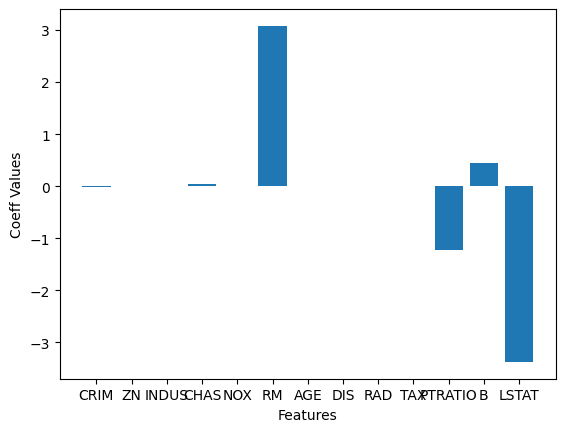

In [15]:
coef=model.coef_
plt.bar(X.columns,coef)
plt.xlabel("Features")
plt.ylabel("Coeff Values")

Alpha=[1.00000000e-03 1.20679264e-03 1.45634848e-03 1.75751062e-03
 2.12095089e-03 2.55954792e-03 3.08884360e-03 3.72759372e-03
 4.49843267e-03 5.42867544e-03 6.55128557e-03 7.90604321e-03
 9.54095476e-03 1.15139540e-02 1.38949549e-02 1.67683294e-02
 2.02358965e-02 2.44205309e-02 2.94705170e-02 3.55648031e-02
 4.29193426e-02 5.17947468e-02 6.25055193e-02 7.54312006e-02
 9.10298178e-02 1.09854114e-01 1.32571137e-01 1.59985872e-01
 1.93069773e-01 2.32995181e-01 2.81176870e-01 3.39322177e-01
 4.09491506e-01 4.94171336e-01 5.96362332e-01 7.19685673e-01
 8.68511374e-01 1.04811313e+00 1.26485522e+00 1.52641797e+00
 1.84206997e+00 2.22299648e+00 2.68269580e+00 3.23745754e+00
 3.90693994e+00 4.71486636e+00 5.68986603e+00 6.86648845e+00
 8.28642773e+00 1.00000000e+01]| Coefficients =[-0.99935912  0.69130002  0.26893579  0.71887992 -2.01602945  3.14586767
 -0.17377772 -3.07491317  2.23334727 -1.74899938 -2.03590048  1.12837163
 -3.61140283]
Alpha=[1.00000000e-03 1.20679264e-03 1.45634848e-03 1.7

Text(0.5, 1.0, 'Lasso Regression')

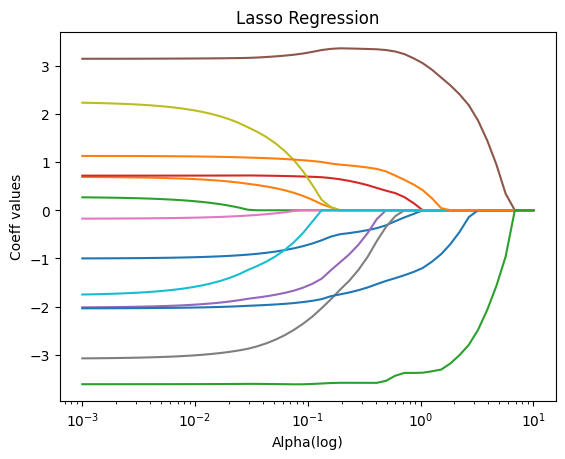

In [16]:
alphas=np.logspace(-3,1,50)
coeff_path=[]
for alph in alphas:
    lasso=Lasso(alpha=alph,max_iter=5000)
    lasso.fit(X_train,y_train)
    coeff_path.append(lasso.coef_)
    print(f"Alpha={alphas}| Coefficients ={lasso.coef_}")
coeff_path=np.array(coeff_path)
plt.plot(alphas,coeff_path)
plt.xscale("log")
plt.xlabel("Alpha(log)")
plt.ylabel("Coeff values")
plt.title("Lasso Regression")